# Visualizing Filtering on the Doubling Map

See Chapter 6, Section 6.3.6: Bootstrap Particle Filter; Chapter 6, Section 6.3.8: Evaluating Probabilistic Estimation.

## Problem setting

This demo focuses on visualizing filtering distributions rather than introducing a new learning algorithm. The state lies on the unit interval with wrap-around dynamics
$$
v_{j+1}=(2v_j+\xi_j)\bmod 1,
$$
where
$$
\xi_j\sim\mathcal{N}(0,\sigma_v^2 I).
$$
The nonlinear observation model is
$$
y_{j+1}=\cos(2\pi v_{j+1})+\eta_{j+1},
$$
with
$$
\eta_{j+1}\sim\mathcal{N}(0,\sigma_y^2 I).
$$
The cosine observation is many-to-one, so the posterior can be multimodal. This makes the example useful for comparing particle-filter densities with EnKF ensembles and for practicing plots that reveal distributional structure rather than only point estimates.


**Parameter exploration.**

- Increase `sigma_y` to make the posterior wider and less tied to the cosine observation.
- Increase `sigma_v` to spread forecast mass around the circle before the analysis step.
- Compare `pf_n` and `enkf_n`: the particle filter represents multimodality more directly, while the EnKF can smear across modes.
- Change `snapshot_steps` inside the default dictionary when you want the posterior panels to focus on early, middle, or late assimilation cycles.

**Recommended test combinations.** Keep unspecified controls at their displayed defaults.

| `sigma_v` | `sigma_y` | `pf_n` | `enkf_n` | Purpose |
|---:|---:|---:|---:|---|
| 0.005 | 0.10 | 8000 | 100 | Sharp observations with clear posterior modes. |
| 0.010 | 0.20 | 10000 | 100 | Balanced default for comparing density views. |
| 0.040 | 0.30 | 12000 | 160 | Diffuse case where heatmaps are more informative than traces. |


## Shared Simulation and Filtering Setup

This cell defines the problem, simulates one truth/observation sequence, and runs both filters. The outputs are intentionally stored with descriptive names so that the later visualization blocks can be read as examples of plotting workflows: first create a clear filtering object, then build several complementary views from the same stored arrays.


In [1]:
#@title Configuration, Dynamics, and Filters
import matplotlib.pyplot as plt
import numpy as np

DEFAULTS = {
    "T": 80,
    "pf_n": 10000,
    "enkf_n": 100,
    "sigma_v": 0.01,
    "sigma_y": 0.20,
    "seed": 42,
    "x0_true": 0.123,
    "pdf_bins": 120,
    "heatmap_bins": 80,
    "pf_traj_subset": 300,
    "quantile_grid": 99,
    "snapshot_steps": (1, 2, 5, 10, 20, 40, 60, 80),
}

use_default = False #@param {type:"boolean"}
T = 80 #@param {type:"slider", min:20, max:120, step:10}
pf_n = 10000 #@param {type:"slider", min:1000, max:20000, step:1000}
enkf_n = 100 #@param {type:"slider", min:30, max:300, step:10}
sigma_v = 0.01 #@param {type:"slider", min:0.0, max:0.08, step:0.005}
sigma_y = 0.20 #@param {type:"slider", min:0.05, max:0.5, step:0.025}
x0_true = 0.123 #@param {type:"number"}
seed = 42 #@param {type:"integer"}

params = DEFAULTS.copy()
if not use_default:
    params.update({
        "T": int(T),
        "pf_n": int(pf_n),
        "enkf_n": int(enkf_n),
        "sigma_v": float(sigma_v),
        "sigma_y": float(sigma_y),
        "x0_true": float(x0_true),
        "seed": int(seed),
    })

T = params["T"]
pf_n = params["pf_n"]
enkf_n = params["enkf_n"]
sigma_v = params["sigma_v"]
sigma_y = params["sigma_y"]
x0_true = params["x0_true"]
seed = params["seed"]
pdf_bins = params["pdf_bins"]
heatmap_bins = params["heatmap_bins"]
pf_traj_subset = params["pf_traj_subset"]
quantile_grid = params["quantile_grid"]
snapshot_steps = tuple(s for s in params["snapshot_steps"] if s <= T)
if not snapshot_steps:
    snapshot_steps = (1, min(T, 2), T)

rng = np.random.default_rng(seed)
TWO_PI = 2.0 * np.pi


def wrap01(x):
    """
    Wrap state values to the interval [0, 1).
    Input: scalar or array x
    Output: wrapped values with the same shape
    """
    return np.mod(x, 1.0)


def h_obs(x):
    """
    Observation function for the doubling-map experiment.
    Input: state value(s) x in [0, 1)
    Output: cos(2*pi*x)
    """
    return np.cos(TWO_PI * x)


def propagate_with_noise(x, noise):
    """
    Propagate state through the noisy doubling map.
    Input: state value(s) x and additive process noise
    Output: next state value(s), wrapped to [0, 1)
    """
    return wrap01(2.0 * x + noise)


def simulate_truth_and_obs(x0_true, T, sigma_v, sigma_y, rng):
    """
    Simulate the true state trajectory and observation sequence.
    Output x_full has length T+1 and includes the initial condition.
    Output y_seq has length T and corresponds to times 1,...,T.
    """
    x_seq = np.empty(T + 1)
    y_seq = np.empty(T)
    x_seq[0] = wrap01(x0_true)
    for t in range(T):
        x_seq[t + 1] = propagate_with_noise(x_seq[t], sigma_v * rng.normal())
        y_seq[t] = h_obs(x_seq[t + 1]) + sigma_y * rng.normal()
    return x_seq, y_seq


def systematic_resample_1d(weights, rng):
    """
    Perform systematic resampling for a one-dimensional particle filter.
    Input: normalized weights
    Output: resampled particle indices
    """
    n = len(weights)
    positions = (rng.uniform() + np.arange(n)) / n
    cumulative = np.cumsum(weights)
    cumulative[-1] = 1.0
    idx = np.zeros(n, dtype=int)
    i = j = 0
    while i < n:
        if positions[i] < cumulative[j]:
            idx[i] = j
            i += 1
        else:
            j += 1
    return idx


def run_pf(y_obs, x0_ens, sigma_v, sigma_y, rng):
    """
    Execute bootstrap particle-filter assimilation cycles.
    The dictionary stores prior particles, posterior particles, weights, ESS,
    and posterior means at every assimilation step.
    """
    x_prev = np.asarray(x0_ens).copy()
    prior, post, weights, ess, prior_mean, post_mean = [], [], [], [], [], []
    for y_t in y_obs:
        x_prior = propagate_with_noise(x_prev, sigma_v * rng.normal(size=x_prev.shape))
        innov = (y_t - h_obs(x_prior)) / sigma_y
        logw = -0.5 * innov * innov
        logw -= np.max(logw)
        w = np.exp(logw)
        w /= np.sum(w)
        ess_t = 1.0 / np.sum(w * w)
        idx = systematic_resample_1d(w, rng)
        x_post = x_prior[idx]
        prior.append(x_prior)
        post.append(x_post)
        weights.append(w)
        ess.append(ess_t)
        prior_mean.append(np.mean(x_prior))
        post_mean.append(np.mean(x_post))
        x_prev = x_post
    return {
        "prior": np.asarray(prior),
        "post": np.asarray(post),
        "weights": np.asarray(weights),
        "ess": np.asarray(ess),
        "prior_mean": np.asarray(prior_mean),
        "post_mean": np.asarray(post_mean),
    }


def run_enkf(y_obs, x0_ens, sigma_v, sigma_y, rng):
    """
    Execute a scalar perturbed-observation EnKF.
    The dictionary stores prior ensembles, posterior ensembles, Kalman gains,
    and ensemble means at every assimilation step.
    """
    x_prev = np.asarray(x0_ens).copy()
    n = len(x_prev)
    prior, post, k_gain, prior_mean, post_mean = [], [], [], [], []
    for y_t in y_obs:
        x_prior = propagate_with_noise(x_prev, sigma_v * rng.normal(size=x_prev.shape))
        y_prior = h_obs(x_prior)
        xm = np.mean(x_prior)
        ym = np.mean(y_prior)
        xc = x_prior - xm
        yc = y_prior - ym
        p_xy = np.mean(xc * yc)
        p_yy = np.mean(yc * yc) + sigma_y * sigma_y + 1e-6
        K = p_xy / p_yy
        y_pert = y_t + sigma_y * rng.normal(size=n)
        x_post = wrap01(x_prior + K * (y_pert - y_prior))
        prior.append(x_prior)
        post.append(x_post)
        k_gain.append(K)
        prior_mean.append(np.mean(x_prior))
        post_mean.append(np.mean(x_post))
        x_prev = x_post
    return {
        "prior": np.asarray(prior),
        "post": np.asarray(post),
        "k_gain": np.asarray(k_gain),
        "prior_mean": np.asarray(prior_mean),
        "post_mean": np.asarray(post_mean),
    }


def hist_pdf(samples, bins=120, weights=None):
    """
    Convert samples on [0, 1) into a histogram density curve.
    """
    hist, edges = np.histogram(samples, bins=bins, range=(0.0, 1.0), density=True, weights=weights)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, hist


def empirical_cdf(samples):
    """
    Compute the empirical cumulative distribution function.
    """
    xs = np.sort(np.asarray(samples))
    cdf = np.arange(1, len(xs) + 1) / len(xs)
    return xs, cdf


def wrapped_kde_pdf_01(samples, grid_size=240, bandwidth=None):
    """
    Build a simple wrapped Gaussian KDE on the unit interval.
    This avoids boundary artifacts at 0 and 1.
    """
    samples = np.mod(np.asarray(samples), 1.0)
    grid = np.linspace(0.0, 1.0, grid_size, endpoint=False)
    if bandwidth is None:
        bandwidth = max(0.01, 1.06 * np.std(samples) * len(samples) ** (-1 / 5))
    diff = grid[:, None] - samples[None, :]
    diff = (diff + 0.5) % 1.0 - 0.5
    pdf = np.exp(-0.5 * (diff / bandwidth) ** 2).mean(axis=1) / (np.sqrt(2 * np.pi) * bandwidth)
    return grid, pdf


def phase_pdf_curve_01(samples):
    """
    Return a smooth density curve for phase/ring plots.
    """
    return wrapped_kde_pdf_01(samples, grid_size=300)


def draw_ring_pdf_fill(ax, phase_grid, pdf_vals, color, alpha, label):
    """
    Draw a filled annulus whose radial thickness is proportional to density.
    """
    theta = TWO_PI * np.mod(phase_grid, 1.0)
    pdf = np.maximum(np.nan_to_num(pdf_vals), 0.0)
    r_outer = np.sqrt(1.0 + pdf / np.pi)
    theta_w = np.concatenate([theta, [theta[0] + TWO_PI]])
    r_outer_w = np.concatenate([r_outer, [r_outer[0]]])
    x_outer = r_outer_w * np.cos(theta_w)
    y_outer = r_outer_w * np.sin(theta_w)
    x_inner = np.cos(theta_w)
    y_inner = np.sin(theta_w)
    poly_x = np.concatenate([x_outer, x_inner[::-1]])
    poly_y = np.concatenate([y_outer, y_inner[::-1]])
    ax.fill(poly_x, poly_y, color=color, alpha=alpha, label=label)


x_true_np, y_obs_np = simulate_truth_and_obs(x0_true, T, sigma_v, sigma_y, rng)
x0_pf = wrap01(x0_true + 0.18 * rng.normal(size=pf_n))
x0_enkf = wrap01(x0_true + 0.18 * rng.normal(size=enkf_n))
pf_out = run_pf(y_obs_np, x0_pf, sigma_v, sigma_y, rng)
enkf_out = run_enkf(y_obs_np, x0_enkf, sigma_v, sigma_y, rng)

pf_prior_np = pf_out["prior"]
pf_post_np = pf_out["post"]
pf_weights_np = pf_out["weights"]
pf_ess_np = pf_out["ess"]
pf_post_mean_np = pf_out["post_mean"]
enkf_prior_np = enkf_out["prior"]
enkf_post_np = enkf_out["post"]
enkf_k_np = enkf_out["k_gain"]
enkf_post_mean_np = enkf_out["post_mean"]

print(f"Generated {T} assimilation steps.")
print(f"Particle filter particles: {pf_n}; EnKF ensemble members: {enkf_n}.")
print(f"Median PF ESS: {np.median(pf_ess_np):.1f}; median EnKF gain: {np.median(enkf_k_np):.3f}.")


Generated 80 assimilation steps.
Particle filter particles: 10000; EnKF ensemble members: 100.
Median PF ESS: 5909.3; median EnKF gain: -0.002.


## System Overview and Particle Trajectories

The first figure checks the basic experiment: the true state, the filtered means, the nonlinear observations, and diagnostics such as effective sample size and EnKF gain. The second figure overlays representative posterior trajectories, which is often the fastest way to see whether an algorithm is tracking the state or merely producing a plausible mean.


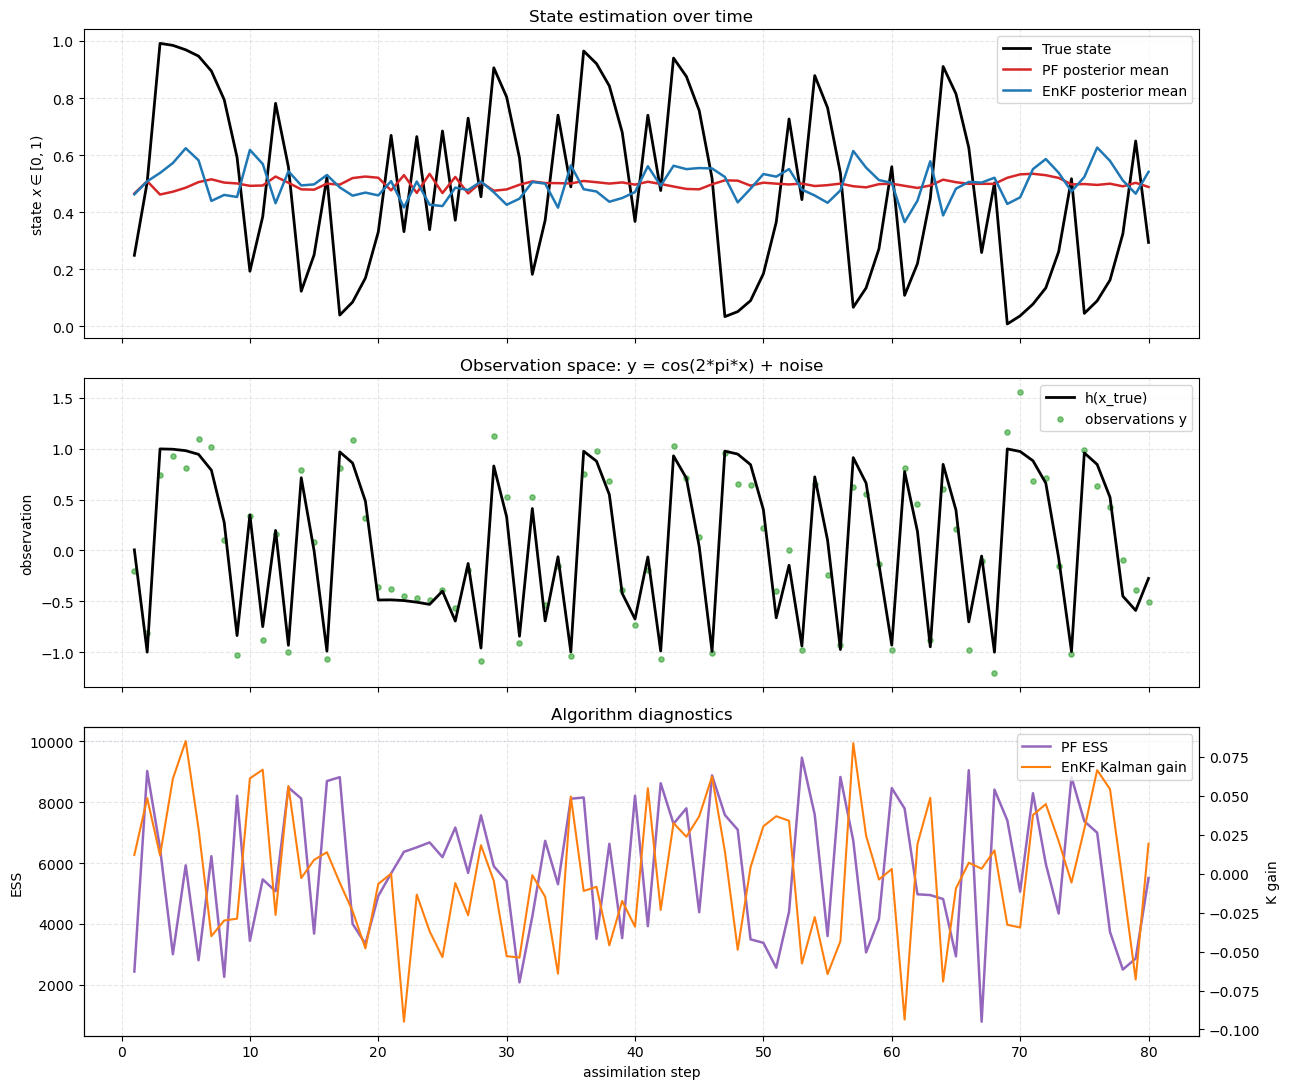

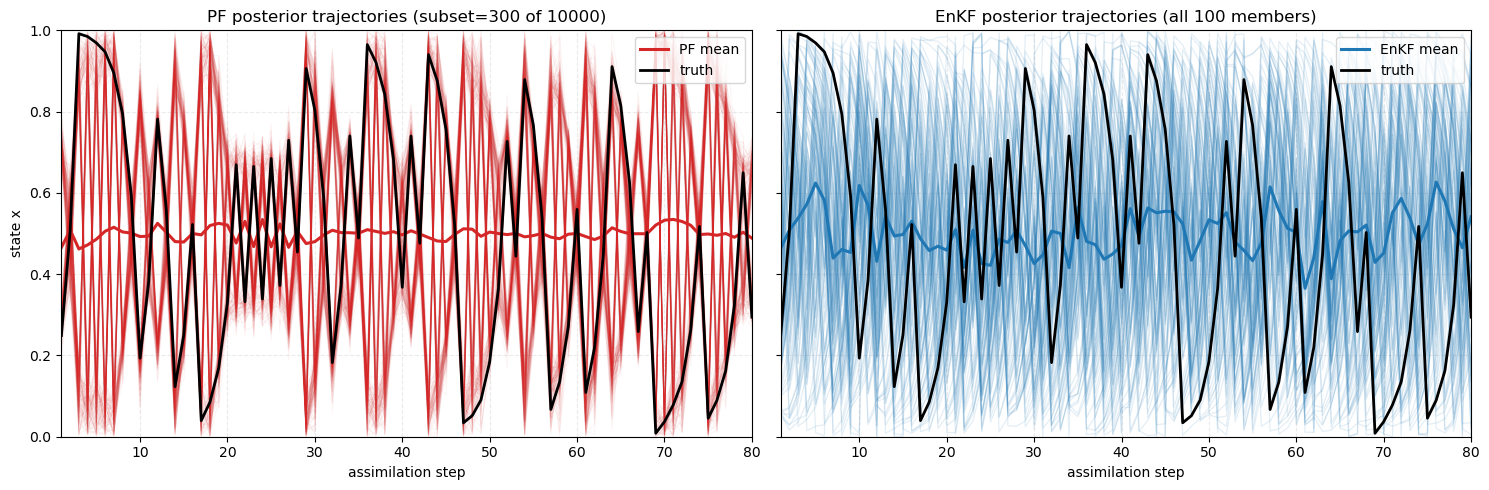

In [2]:
#@title System Overview & Particle Trajectories
t = np.arange(1, T + 1)

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
axes[0].plot(t, x_true_np[1:], color="black", linewidth=2.0, label="True state")
axes[0].plot(t, pf_post_mean_np, color="tab:red", linewidth=1.8, label="PF posterior mean")
axes[0].plot(t, enkf_post_mean_np, color="tab:blue", linewidth=1.8, label="EnKF posterior mean")
axes[0].set_ylabel(r"state $x \in [0,1)$")
axes[0].set_title("State estimation over time")
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].legend(loc="upper right")

axes[1].plot(t, h_obs(x_true_np[1:]), color="black", linewidth=2.0, label="h(x_true)")
axes[1].scatter(t, y_obs_np, s=14, alpha=0.6, color="tab:green", label="observations y")
axes[1].set_ylabel("observation")
axes[1].set_title("Observation space: y = cos(2*pi*x) + noise")
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].legend(loc="upper right")

ax3 = axes[2]
ax3.plot(t, pf_ess_np, color="tab:purple", linewidth=1.8, label="PF ESS")
ax3.axhline(pf_n, color="tab:purple", alpha=0.25, linestyle=":", linewidth=1.0)
ax3.set_ylabel("ESS")
ax3.grid(alpha=0.3, linestyle="--")
ax3.set_xlabel("assimilation step")

ax3b = ax3.twinx()
ax3b.plot(t, enkf_k_np, color="tab:orange", linewidth=1.5, label="EnKF Kalman gain")
ax3b.set_ylabel("K gain")

h1, l1 = ax3.get_legend_handles_labels()
h2, l2 = ax3b.get_legend_handles_labels()
ax3.legend(h1 + h2, l1 + l2, loc="upper right")
axes[2].set_title("Algorithm diagnostics")
plt.tight_layout()
plt.show()

rng_traj = np.random.default_rng(seed)
subset_idx = rng_traj.choice(pf_n, size=min(pf_traj_subset, pf_n), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for j in subset_idx:
    axes[0].plot(t, pf_post_np[:, j], color="tab:red", alpha=0.05, linewidth=0.7)
axes[0].plot(t, pf_post_mean_np, color="tab:red", linewidth=2.2, label="PF mean")
axes[0].plot(t, x_true_np[1:], color="black", linewidth=2.0, label="truth")
axes[0].set_title(f"PF posterior trajectories (subset={len(subset_idx)} of {pf_n})")
axes[0].set_xlabel("assimilation step")
axes[0].set_ylabel("state x")
axes[0].grid(alpha=0.25, linestyle="--")
axes[0].legend(loc="upper right")

for j in range(enkf_n):
    axes[1].plot(t, enkf_post_np[:, j], color="tab:blue", alpha=0.12, linewidth=0.9)
axes[1].plot(t, enkf_post_mean_np, color="tab:blue", linewidth=2.2, label="EnKF mean")
axes[1].plot(t, x_true_np[1:], color="black", linewidth=2.0, label="truth")
axes[1].set_title(f"EnKF posterior trajectories (all {enkf_n} members)")
axes[1].set_xlabel("assimilation step")
axes[1].grid(alpha=0.25, linestyle="--")
axes[1].legend(loc="upper right")

for ax in axes:
    ax.set_xlim(1, T)
    ax.set_ylim(0.0, 1.0)
plt.tight_layout()
plt.show()


## Prior and Posterior Snapshots

Snapshot panels compare the forecast and analysis distributions at selected assimilation times. PDFs emphasize modal structure and spread, while empirical CDFs provide a less smoothed view of distributional movement. Showing both helps avoid over-interpreting a single density estimate.


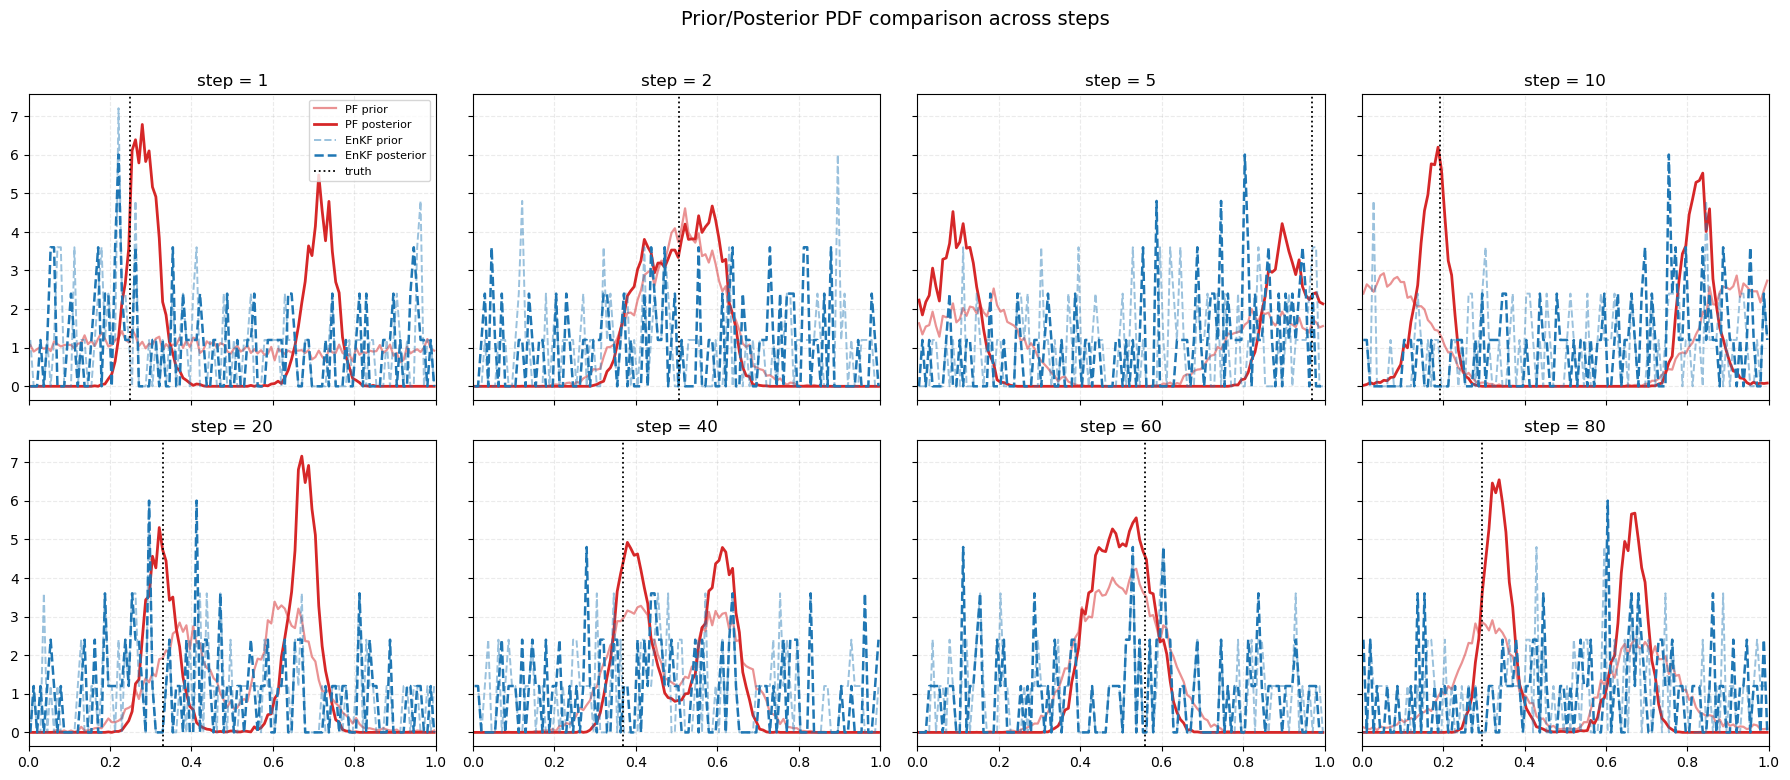

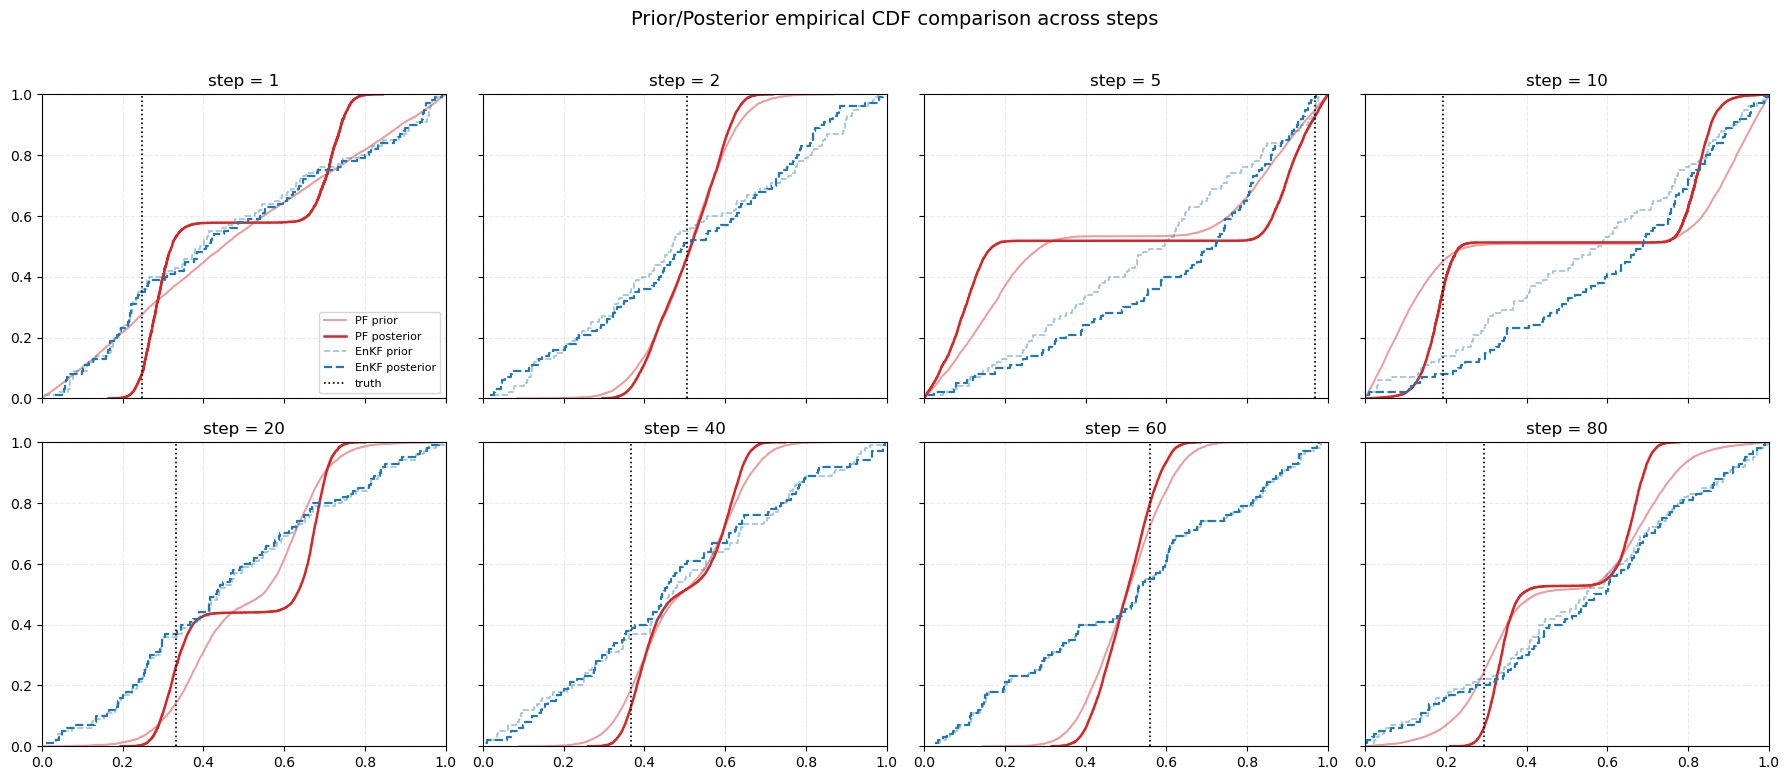

In [3]:
#@title Prior vs Posterior Snapshots
snapshot_idx = [s - 1 for s in snapshot_steps if 1 <= s <= T]
ncols = 4
nrows = int(np.ceil(len(snapshot_idx) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.8 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for i, k in enumerate(snapshot_idx):
    ax = axes[i]
    xg_pf_pr, pdf_pf_pr = hist_pdf(pf_prior_np[k], bins=pdf_bins)
    xg_pf_po, pdf_pf_po = hist_pdf(pf_post_np[k], bins=pdf_bins)
    xg_ek_pr, pdf_ek_pr = hist_pdf(enkf_prior_np[k], bins=pdf_bins)
    xg_ek_po, pdf_ek_po = hist_pdf(enkf_post_np[k], bins=pdf_bins)

    ax.plot(xg_pf_pr, pdf_pf_pr, color="tab:red", alpha=0.5, linewidth=1.6, label="PF prior")
    ax.plot(xg_pf_po, pdf_pf_po, color="tab:red", linewidth=2.0, label="PF posterior")
    ax.plot(xg_ek_pr, pdf_ek_pr, color="tab:blue", alpha=0.45, linewidth=1.4, linestyle="--", label="EnKF prior")
    ax.plot(xg_ek_po, pdf_ek_po, color="tab:blue", linewidth=1.8, linestyle="--", label="EnKF posterior")

    xt = x_true_np[k + 1]
    ax.axvline(xt, color="black", linewidth=1.3, linestyle=":", label="truth")
    ax.set_title(f"step = {k+1}")
    ax.grid(alpha=0.25, linestyle="--")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")
axes[0].legend(loc="upper right", fontsize=8)
for ax in axes:
    if ax.has_data():
        ax.set_xlim(0.0, 1.0)
fig.suptitle("Prior/Posterior PDF comparison across steps", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.8 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for i, k in enumerate(snapshot_idx):
    ax = axes[i]
    spf_pr, cpf_pr = empirical_cdf(pf_prior_np[k])
    spf_po, cpf_po = empirical_cdf(pf_post_np[k])
    sek_pr, cek_pr = empirical_cdf(enkf_prior_np[k])
    sek_po, cek_po = empirical_cdf(enkf_post_np[k])

    ax.step(spf_pr, cpf_pr, where="post", color="tab:red", alpha=0.45, linewidth=1.4, label="PF prior")
    ax.step(spf_po, cpf_po, where="post", color="tab:red", linewidth=1.8, label="PF posterior")
    ax.step(sek_pr, cek_pr, where="post", color="tab:blue", alpha=0.45, linewidth=1.2, linestyle="--", label="EnKF prior")
    ax.step(sek_po, cek_po, where="post", color="tab:blue", linewidth=1.6, linestyle="--", label="EnKF posterior")

    xt = x_true_np[k + 1]
    ax.axvline(xt, color="black", linewidth=1.2, linestyle=":", label="truth")
    ax.set_title(f"step = {k+1}")
    ax.grid(alpha=0.25, linestyle="--")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")
axes[0].legend(loc="lower right", fontsize=8)
for ax in axes:
    if ax.has_data():
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(0.0, 1.0)
fig.suptitle("Prior/Posterior empirical CDF comparison across steps", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


## Ring, Heatmap, and PDF Transport Views

The state is periodic, so a linear plot on $[0,1)$ can hide wrap-around behavior. Ring-density plots respect the topology of the state space. Time-density heatmaps show when uncertainty grows or collapses. Quantile arrows give a compact visual summary of how the prior distribution moves toward the posterior distribution at one assimilation step.


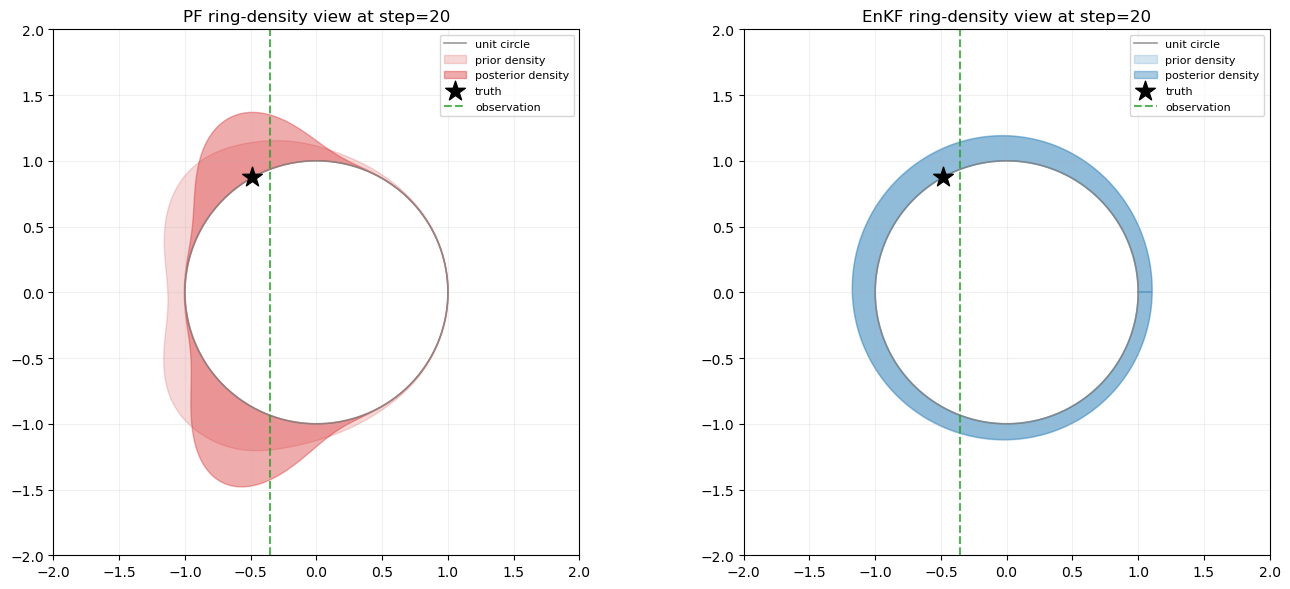

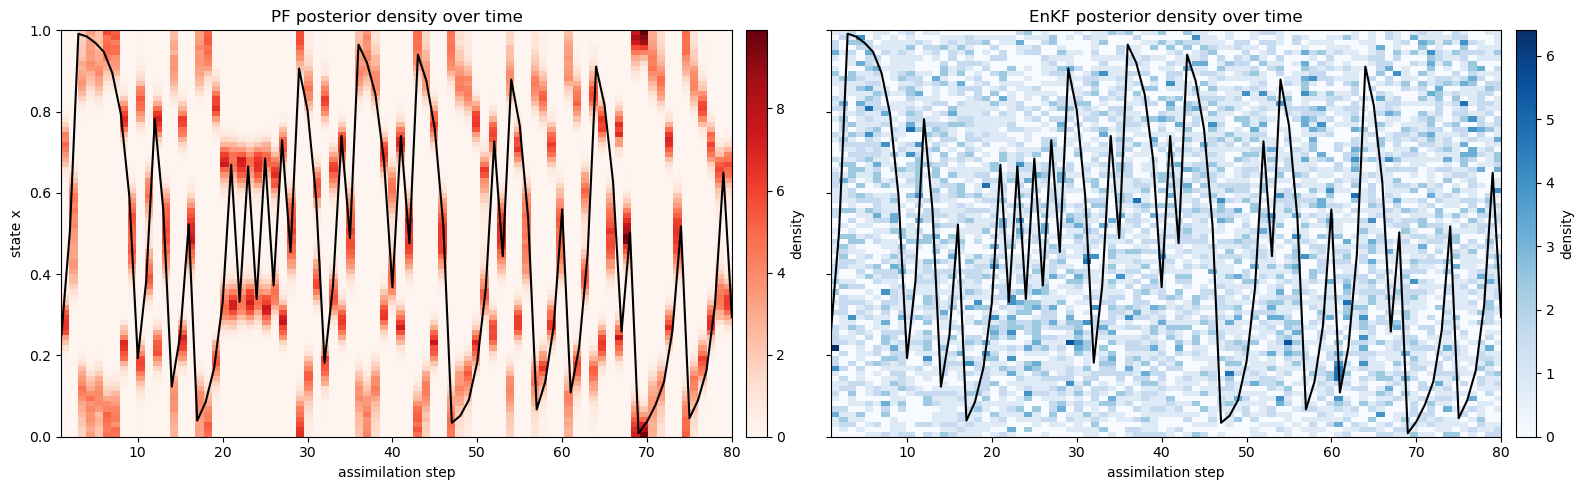

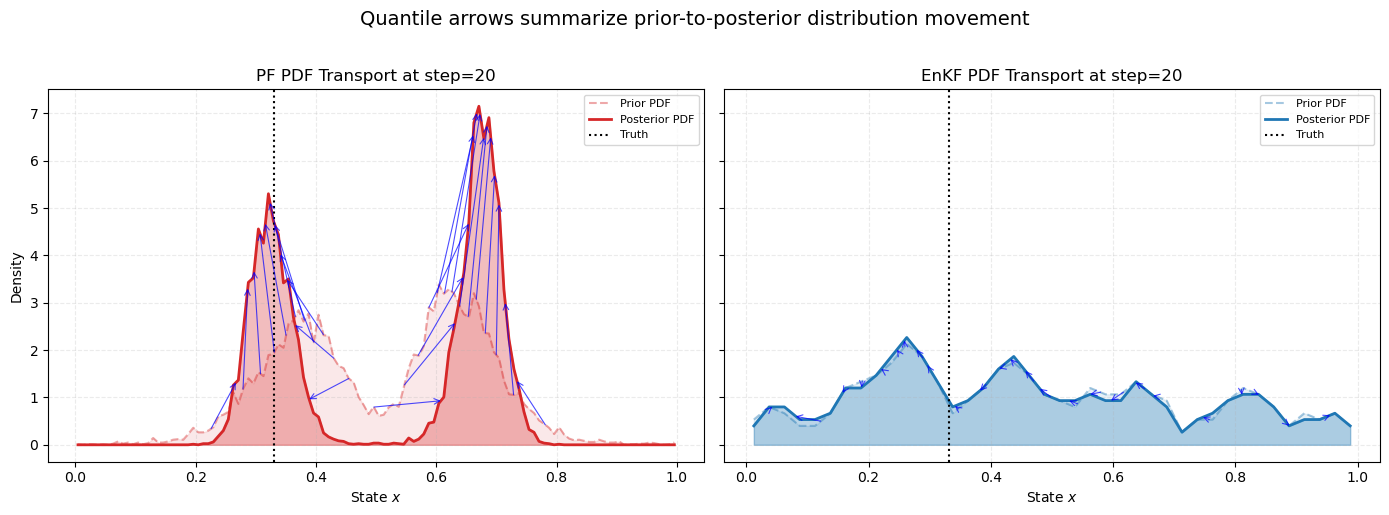

In [4]:
#@title Advanced Visualizations: Ring, Heatmap, and PDF Transport

def smooth_pdf(pdf, window=3):
    """
    Smooth a 1D density curve using a moving average.
    """
    w = np.ones(window) / window
    return np.convolve(pdf, w, mode="same")

focus_step = 20 if T >= 20 else T
k = focus_step - 1

# --- 1) Ring Density View ---
phase_pf_prior = np.mod(pf_prior_np[k], 1.0)
phase_pf_post = np.mod(pf_post_np[k], 1.0)
phase_ek_prior = np.mod(enkf_prior_np[k], 1.0)
phase_ek_post = np.mod(enkf_post_np[k], 1.0)

pg_pf_pr, pdf_pf_pr = phase_pdf_curve_01(phase_pf_prior)
pg_pf_po, pdf_pf_po = phase_pdf_curve_01(phase_pf_post)
pg_ek_pr, pdf_ek_pr = phase_pdf_curve_01(phase_ek_prior)
pg_ek_po, pdf_ek_po = phase_pdf_curve_01(phase_ek_post)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, title, pg_pr, p_pr, pg_po, p_po, col in [
    (axes[0], "PF", pg_pf_pr, pdf_pf_pr, pg_pf_po, pdf_pf_po, "tab:red"),
    (axes[1], "EnKF", pg_ek_pr, pdf_ek_pr, pg_ek_po, pdf_ek_po, "tab:blue"),
]:
    phi = np.linspace(0, 2 * np.pi, 600)
    ax.plot(np.cos(phi), np.sin(phi), color="gray", linewidth=1.2, alpha=0.8, label="unit circle")
    draw_ring_pdf_fill(ax, pg_pr, p_pr, color=col, alpha=0.18, label="prior density")
    draw_ring_pdf_fill(ax, pg_po, p_po, color=col, alpha=0.38, label="posterior density")

    theta_true = 2.0 * np.pi * np.mod(x_true_np[k + 1], 1.0)
    ax.scatter(np.cos(theta_true), np.sin(theta_true), marker="*", s=220, c="black", zorder=10, label="truth")
    obs_x = np.clip(y_obs_np[k], -1.2, 1.2)
    ax.axvline(obs_x, color="tab:green", linestyle="--", linewidth=1.5, alpha=0.8, label="observation")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-2.0, 2.0)
    ax.set_title(f"{title} ring-density view at step={focus_step}")
    ax.grid(alpha=0.18)
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# --- 2) Temporal Density Heatmap ---
def density_matrix(samples_tn, bins=80):
    """
    Compute temporal density matrix for heatmap generation.
    Input shape is time x samples.
    """
    mats = []
    edges = None
    for j in range(samples_tn.shape[0]):
        h, edges = np.histogram(samples_tn[j], bins=bins, range=(0.0, 1.0), density=True)
        mats.append(h)
    mat = np.asarray(mats).T
    centers = 0.5 * (edges[:-1] + edges[1:])
    return mat, centers

pf_mat, ybins = density_matrix(pf_post_np, bins=heatmap_bins)
enkf_mat, _ = density_matrix(enkf_post_np, bins=heatmap_bins)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
im0 = axes[0].imshow(pf_mat, origin="lower", aspect="auto", extent=[1, T, 0.0, 1.0], cmap="Reds")
axes[0].plot(np.arange(1, T + 1), x_true_np[1:], color="black", linewidth=1.5)
axes[0].set_title("PF posterior density over time")
axes[0].set_xlabel("assimilation step")
axes[0].set_ylabel("state x")
im1 = axes[1].imshow(enkf_mat, origin="lower", aspect="auto", extent=[1, T, 0.0, 1.0], cmap="Blues")
axes[1].plot(np.arange(1, T + 1), x_true_np[1:], color="black", linewidth=1.5)
axes[1].set_title("EnKF posterior density over time")
axes[1].set_xlabel("assimilation step")

cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02)
cbar0.set_label("density")
cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02)
cbar1.set_label("density")
plt.tight_layout()
plt.show()

# --- 3) PDF Transport Visualization ---
q_levels = np.linspace(0.02, 0.98, 25)
enkf_pdf_bins = 40

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, title, pr_samples, po_samples, col, bins, do_smooth in [
    (axes[0], "PF", pf_prior_np[k], pf_post_np[k], "tab:red", pdf_bins, False),
    (axes[1], "EnKF", enkf_prior_np[k], enkf_post_np[k], "tab:blue", enkf_pdf_bins, True),
]:
    xg_pr, pdf_pr = hist_pdf(pr_samples, bins=bins)
    xg_po, pdf_po = hist_pdf(po_samples, bins=bins)

    if do_smooth:
        pdf_pr = smooth_pdf(pdf_pr, window=3)
        pdf_po = smooth_pdf(pdf_po, window=3)

    ax.plot(xg_pr, pdf_pr, color=col, alpha=0.4, linestyle="--", linewidth=1.5, label="Prior PDF")
    ax.fill_between(xg_pr, pdf_pr, color=col, alpha=0.1)

    ax.plot(xg_po, pdf_po, color=col, linewidth=2.0, label="Posterior PDF")
    ax.fill_between(xg_po, pdf_po, color=col, alpha=0.3)

    x_pr_q = np.quantile(pr_samples, q_levels)
    x_po_q = np.quantile(po_samples, q_levels)

    y_pr_q = np.interp(x_pr_q, xg_pr, pdf_pr)
    y_po_q = np.interp(x_po_q, xg_po, pdf_po)

    for x0, y0, x1, y1 in zip(x_pr_q, y_pr_q, x_po_q, y_po_q):
        ax.annotate(
            "", xy=(x1, y1), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", color="blue", alpha=0.7, shrinkA=0, shrinkB=0, linewidth=0.8)
        )

    ax.axvline(x_true_np[k + 1], color="black", linestyle=":", linewidth=1.5, label="Truth")
    ax.set_title(f"{title} PDF Transport at step={focus_step}")
    ax.set_xlabel("State $x$")
    ax.grid(alpha=0.25, linestyle="--")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Density")
fig.suptitle("Quantile arrows summarize prior-to-posterior distribution movement", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


## Animated Ring Density

Animations are useful when the posterior shape changes rapidly. The animation below updates prior and posterior ring densities for the particle filter and EnKF side by side, while marking the truth and observation at each step.


In [5]:
#@title Animation Visualization: PF vs EnKF Ring Density
from matplotlib import animation
import matplotlib.patches as mpatches
from IPython.display import HTML


def get_ring_polygon(phase_grid, pdf_vals):
    """
    Calculate polygon vertices for ring density visualization.
    Input: phase_grid and density values
    Output: polygon vertices with shape (2N, 2)
    """
    theta = 2.0 * np.pi * np.mod(phase_grid, 1.0)
    pdf = np.maximum(np.nan_to_num(pdf_vals), 0.0)
    r_outer = np.sqrt(1.0 + pdf / np.pi)

    theta_w = np.concatenate([theta, [theta[0] + 2.0 * np.pi]])
    r_outer_w = np.concatenate([r_outer, [r_outer[0]]])

    x_outer = r_outer_w * np.cos(theta_w)
    y_outer = r_outer_w * np.sin(theta_w)
    x_inner = np.cos(theta_w)
    y_inner = np.sin(theta_w)

    poly_x = np.concatenate([x_outer, x_inner[::-1]])
    poly_y = np.concatenate([y_outer, y_inner[::-1]])
    return np.column_stack([poly_x, poly_y])


anim_steps = min(T, 50)
fig_anim_ring, axes_anim_ring = plt.subplots(1, 2, figsize=(14, 6))
plt.close(fig_anim_ring)

patches = {"pf_pr": None, "pf_po": None, "ek_pr": None, "ek_po": None}
scatters = {"pf_true": None, "ek_true": None}
lines = {"pf_obs": None, "ek_obs": None}

phi = np.linspace(0, 2 * np.pi, 600)
circle_x = np.cos(phi)
circle_y = np.sin(phi)

for i, (title, col) in enumerate([("PF", "tab:red"), ("EnKF", "tab:blue")]):
    ax = axes_anim_ring[i]
    ax.plot(circle_x, circle_y, color="gray", linewidth=1.2, alpha=0.8, label="unit circle")

    p_pr = mpatches.Polygon(np.empty((0, 2)), color=col, alpha=0.18, label="prior density")
    p_po = mpatches.Polygon(np.empty((0, 2)), color=col, alpha=0.38, label="posterior density")
    ax.add_patch(p_pr)
    ax.add_patch(p_po)

    obs_line = ax.axvline(0, color="tab:green", linestyle="--", linewidth=1.5, alpha=0.8, label="observation")
    true_scatter = ax.scatter([], [], marker="*", s=220, c="black", zorder=10, label="truth")

    if i == 0:
        patches["pf_pr"], patches["pf_po"] = p_pr, p_po
        scatters["pf_true"], lines["pf_obs"] = true_scatter, obs_line
    else:
        patches["ek_pr"], patches["ek_po"] = p_pr, p_po
        scatters["ek_true"], lines["ek_obs"] = true_scatter, obs_line

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-2.0, 2.0)
    ax.grid(alpha=0.18)
    ax.legend(loc="upper right", fontsize=8)


def animate_ring(k):
    """
    Update animation frames for ring density visualization.
    Input: k, the time index
    Output: list of updated artist objects
    """
    phase_pf_prior = np.mod(pf_prior_np[k], 1.0)
    phase_pf_post = np.mod(pf_post_np[k], 1.0)
    pg_pf_pr, pdf_pf_pr = phase_pdf_curve_01(phase_pf_prior)
    pg_pf_po, pdf_pf_po = phase_pdf_curve_01(phase_pf_post)

    patches["pf_pr"].set_xy(get_ring_polygon(pg_pf_pr, pdf_pf_pr))
    patches["pf_po"].set_xy(get_ring_polygon(pg_pf_po, pdf_pf_po))

    theta_true = 2.0 * np.pi * np.mod(x_true_np[k + 1], 1.0)
    true_pos = [[np.cos(theta_true), np.sin(theta_true)]]
    scatters["pf_true"].set_offsets(true_pos)

    obs_x = np.clip(y_obs_np[k], -1.2, 1.2)
    lines["pf_obs"].set_xdata([obs_x, obs_x])
    axes_anim_ring[0].set_title(f"PF Ring Density (Step {k+1})")

    phase_ek_prior = np.mod(enkf_prior_np[k], 1.0)
    phase_ek_post = np.mod(enkf_post_np[k], 1.0)
    pg_ek_pr, pdf_ek_pr = phase_pdf_curve_01(phase_ek_prior)
    pg_ek_po, pdf_ek_po = phase_pdf_curve_01(phase_ek_post)

    patches["ek_pr"].set_xy(get_ring_polygon(pg_ek_pr, pdf_ek_pr))
    patches["ek_po"].set_xy(get_ring_polygon(pg_ek_po, pdf_ek_po))

    scatters["ek_true"].set_offsets(true_pos)
    lines["ek_obs"].set_xdata([obs_x, obs_x])
    axes_anim_ring[1].set_title(f"EnKF Ring Density (Step {k+1})")

    return list(patches.values()) + list(scatters.values()) + list(lines.values())


anim_ring = animation.FuncAnimation(fig_anim_ring, animate_ring, frames=anim_steps, interval=400, blit=True)
HTML(anim_ring.to_jshtml())
